# Classical Orbits and Their Initial Conditions

### How do the initial conditions of a gravitationally bound system change the stability, path, and properties of the orbits?

##### An analysis of classical orbits by Yan Kai Chng, Ethan Hogan, Alejandro Balderas Munoz, and Owen Sliger

In [5]:
import numpy as np
import plotly.express as px
import pandas as pd

The first objective to creating a simulation of gravitational orbits is to find what matters:

We decided that for any gravitational system, we could treat the objects as point masses, objects that have no volume or internal rotation, but contain a theoretical mass, position, and momentum. Since we want to focus on interactions within the system, we chose to exclude any external energies. Meaning that the only force in our system is the force between the objects. We also assumed that there would be no friction or drag, and that objects would not collide or merge together. We believe that these assumption would not affect the core question of initial conditions and orbital behavior.

For the sake of interest, we are also treating the objects as 'stars' and 'planets', i.e. our gravitational systems will have a very wide range of masses with no electromagnetic interaction; and we will continue to imagine that our simulation is modeling a celestial system in empty space. This connection will allow us to use our findings to relate the initial conditions of a simulation to real world phenomena and orbital mechanics. 

---

To simulate multi-body gravity, we are going to need a way to describe and track the information tied to our celestial bodies. 

An object in motion, under some force can be described by its:

- mass value
- position in x,y,z space
- momentum in x,y,z space
- and the force on the object in x,y,z space

To unify all of these variables under one designated object, our group decided to use numpy arrays

In [53]:
N = 3
objects = np.zeros([N,10], dtype='object')

for n in range(N):
    objects[n,0:10] = ([f'm{n}', f'x{n}', f'y{n}', f'z{n}', f'px{n}', f'py{n}', f'pz{n}', f'fx{n}', f'fy{n}', f'fz{n}'])

print(f'System 1: \n {objects} \n')

N = 5
objects = np.zeros([N,10], dtype='object')

for n in range(N):
    objects[n,0:10] = ([f'm{n}', f'x{n}', f'y{n}', f'z{n}', f'px{n}', f'py{n}', f'pz{n}', f'fx{n}', f'fy{n}', f'fz{n}'])

print(f'System 2: \n {objects} \n')

System 1: 
 [['m0' 'x0' 'y0' 'z0' 'px0' 'py0' 'pz0' 'fx0' 'fy0' 'fz0']
 ['m1' 'x1' 'y1' 'z1' 'px1' 'py1' 'pz1' 'fx1' 'fy1' 'fz1']
 ['m2' 'x2' 'y2' 'z2' 'px2' 'py2' 'pz2' 'fx2' 'fy2' 'fz2']] 

System 2: 
 [['m0' 'x0' 'y0' 'z0' 'px0' 'py0' 'pz0' 'fx0' 'fy0' 'fz0']
 ['m1' 'x1' 'y1' 'z1' 'px1' 'py1' 'pz1' 'fx1' 'fy1' 'fz1']
 ['m2' 'x2' 'y2' 'z2' 'px2' 'py2' 'pz2' 'fx2' 'fy2' 'fz2']
 ['m3' 'x3' 'y3' 'z3' 'px3' 'py3' 'pz3' 'fx3' 'fy3' 'fz3']
 ['m4' 'x4' 'y4' 'z4' 'px4' 'py4' 'pz4' 'fx4' 'fy4' 'fz4']] 



With these mock 'objects' arrays, we can see how different system with different numbers of bodies can track all the variables we need by storing and changing the properties of each object depending on position of the variable in the numpy array. Our group used the convention:

Column 0 = mass

Column 1, 2, 3 = x-position, y-position, z-position

Column 4, 5, 6 = x-momentum, y-momentum, z-momentum

Column 7, 8, 9 = x-force, y-force, z-force

This creates segmented vectors that describe each property that we care about for each body. $\vec{r}$ represents the position vector from the origin $objects[:,1:4]$, $\vec{p}$ represents the momentum vector from the bodies position $objects[:,4:7]$, and $\vec{F}$ represents the force vector on the body $objects[:,7:10]$

---

Since the bodies are only gravitationally bound, we are going to need to derive a force equation that can be generalized for any body and its state.

We can starts with Newton's law of universal gravitation, which states that:

$$F = \frac{G m_1 m_2}{r^2},$$

where G is the graviational constant, m1 and m2 is the mass of object 1 and 2, and r is the distance between our two masses. 


The following code block is a list of all functions

In [2]:
def init_objects(R, M, vm):
    objects[i,0:3] = R * np.array((np.random.random(),np.random.random(),np.random.random()))
    objects[i,3] = M * (1 - np.random.random()) #(1-random.random()) since random.random() returns values on the interval [0.0, 1.0)
    objects[i,4:7] = vm * objects[i,3] * np.array((np.random.random(),np.random.random(),np.random.random()))
    
    return(objects)

def force_calculation(objects, N, G, soft_len, t, dt, frame_num):
    #Sets force equal to 0
    objects[:,7:10] = 0
    
    #Records current object position and frame
    if frame_num % frame_skip == 0:
        for i in range(N):
            frames.append((objects[i,0], objects[i,1], objects[i,2], str(i), frame_num/frame_skip))
    
    #Calculating the force between every object
    for i in range(N):
        for j in range(i+1,N):
            if i != j:
                r = objects[j,0:3] - objects[i,0:3]
                r_dot = np.dot(r,r)
                
                F = G * objects[i,3] * objects[j,3] * (r / (r_dot + soft_len**2)**1.5)
                
                objects[i,7:10] += F
                objects[j,7:10] -= F
    
    #Updating momentum
    objects[:,4:7] += objects[:,7:10] * dt
    
    #Updating Position
    for i in range(N): #Put in for loop so that mass is a scalar instead of an array of different shape from momentum. [find better solution?]
        objects[i,0:3] += (objects[i,4:7] / objects[i,3]) * dt
    
    return(frames)

## Circular Elliptical Orbit

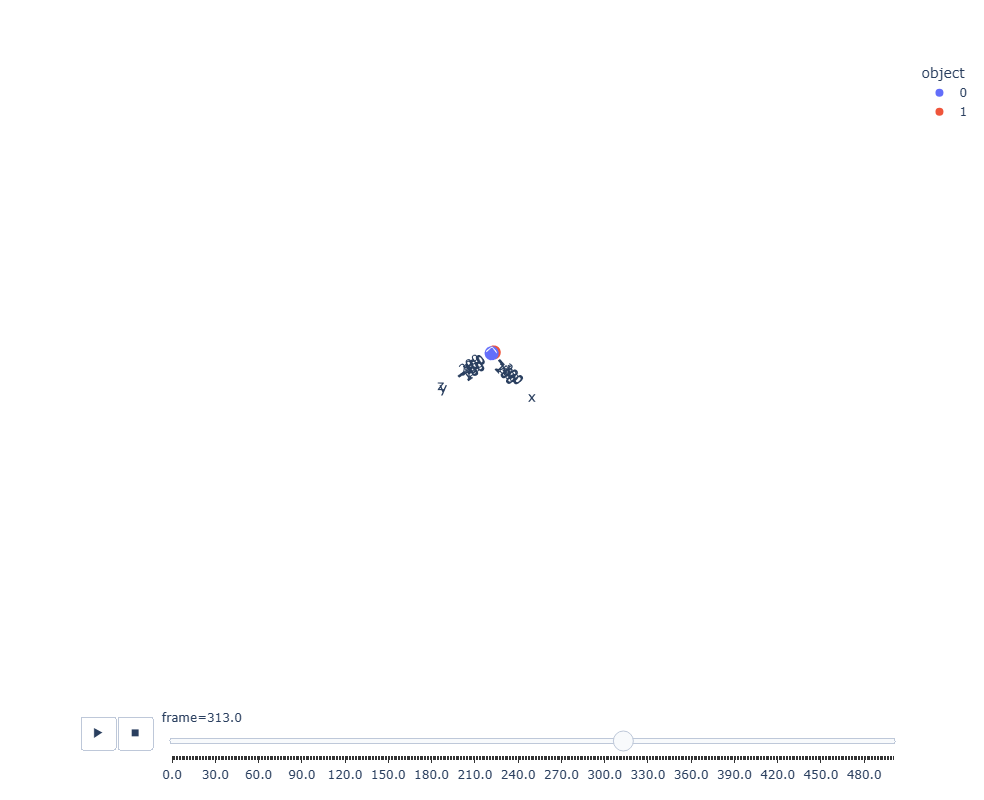

In [5]:
N = 2 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 50 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 20

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 5000
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((100,0,0))
objects[1,3] = 1
objects[1,4:7] = np.array((0,7.5,0))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10*R, 10*R]),
        yaxis=dict(range=[-10*R, 10*R]),
        zaxis=dict(range=[-10*R, 10*R]),
        aspectmode='cube'
    )
)

fig.show()

## Circular Elliptical Orbit In Non-Unit Planes

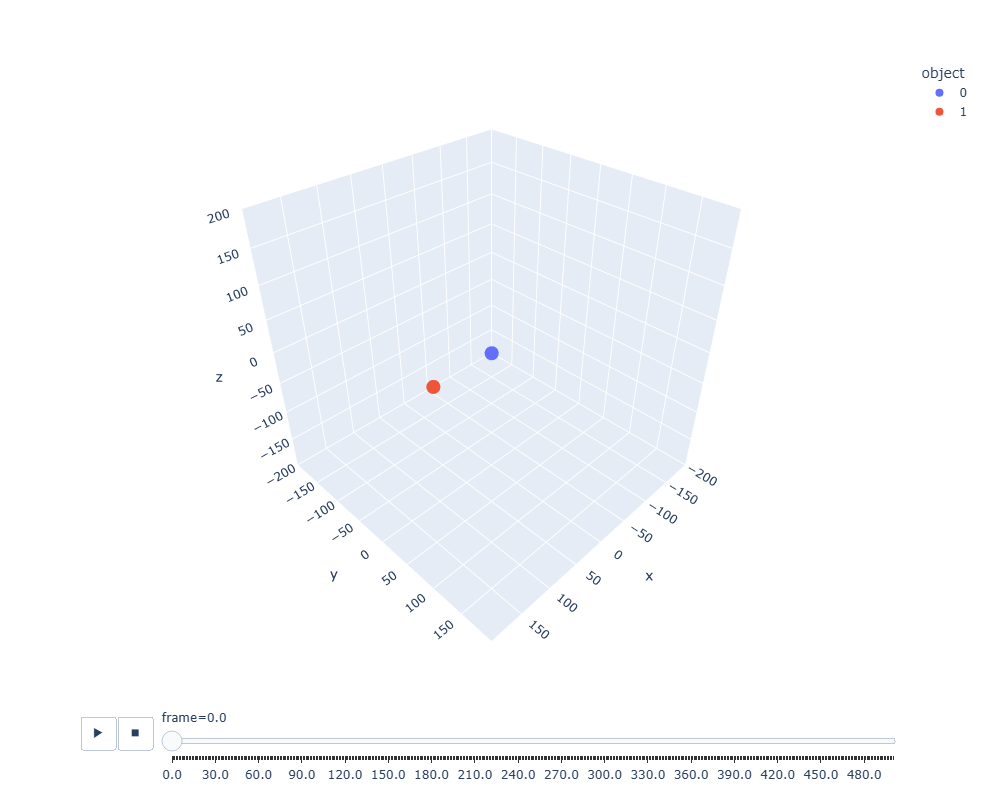

In [33]:
N = 2 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 50 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 20

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 5000
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((100,0,0))
objects[1,3] = 1
objects[1,4:7] = np.array((0,28**(0.5),28.25**(0.5)))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10*R, 10*R]),
        yaxis=dict(range=[-10*R, 10*R]),
        zaxis=dict(range=[-10*R, 10*R]),
        aspectmode='cube'
    )
)

fig.show()

## Three Body Orbitals

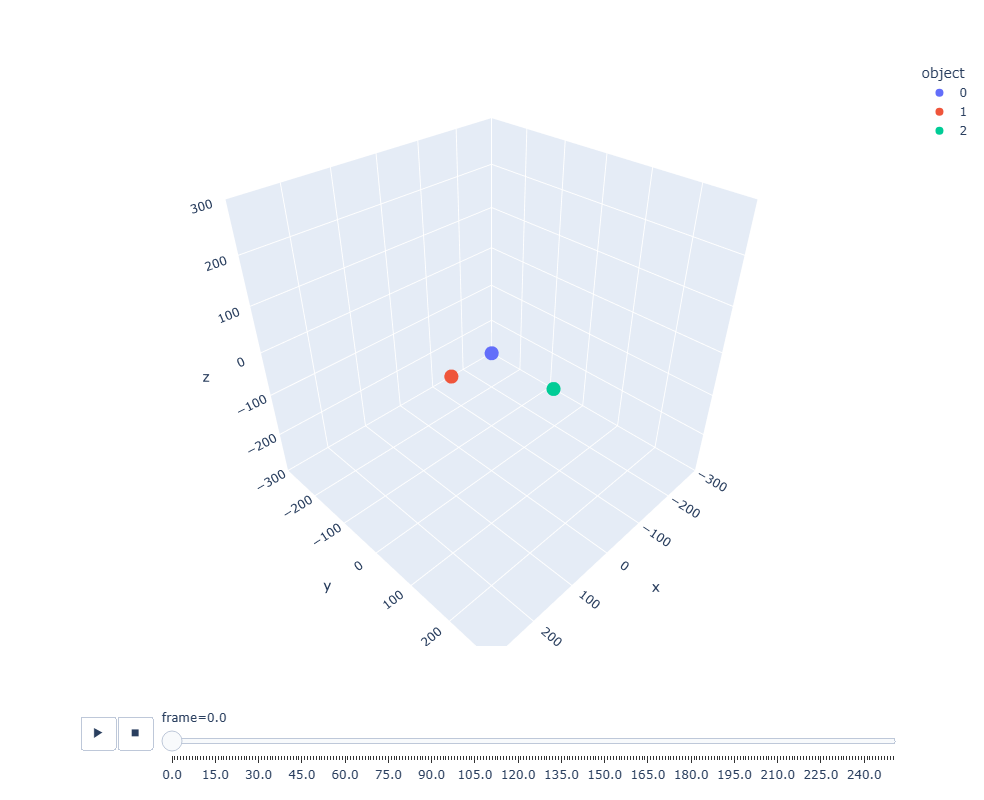

In [4]:
N = 3 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 100 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 30

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 5000
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((100,0,0))
objects[1,3] = 1
objects[1,4:7] = np.array((0,28**(0.5),28.25**(0.5)))

objects[2,0:3] = np.array((0,150,0))
objects[2,3] = 1
objects[2,4:7] = np.array((-6,0,0))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10*R, 10*R]),
        yaxis=dict(range=[-10*R, 10*R]),
        zaxis=dict(range=[-10*R, 10*R]),
        aspectmode='cube'
    )
)

fig.show()

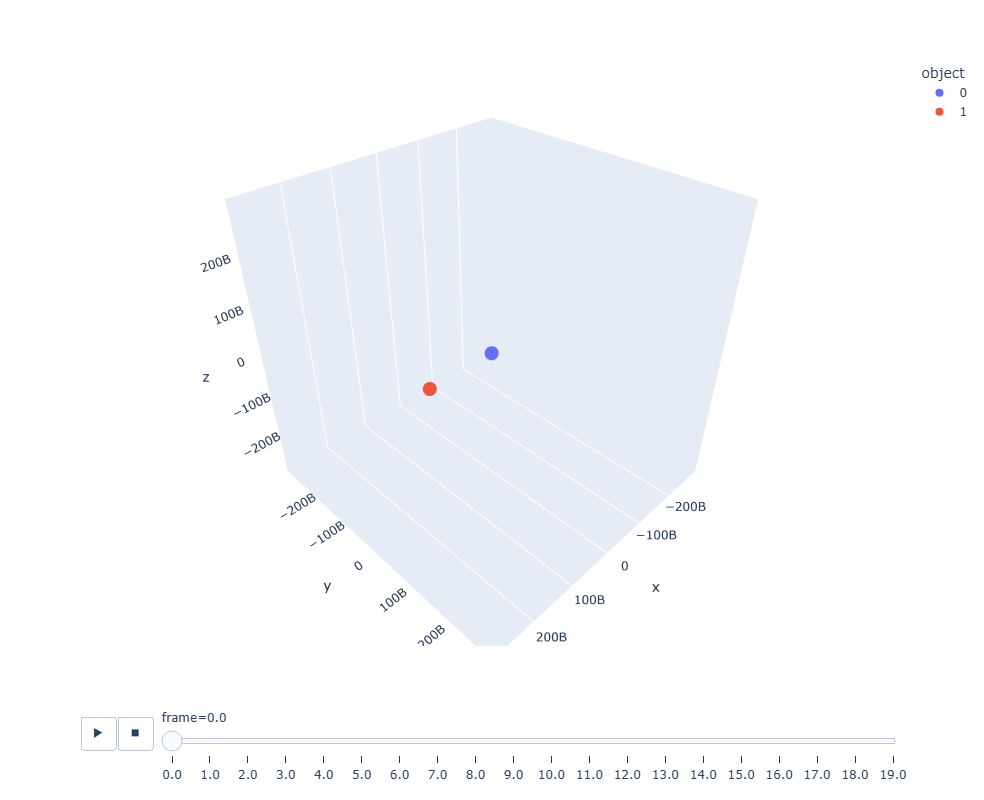

In [3]:
N = 2 #Number of objects
dt = 0.001 #Timestep
s_prime = 3.175*10**(-7)
Time = 100 #Duration of the simulation
frame_skip = 5000 #Number of timesteps between frames
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 6.67*10**(-11)/(s_prime*dt) #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)
R = 1.496*10**11

t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

objects[0,0:3] = np.array((0,0,0))
objects[0,3] = 1.989*10**(30)
objects[0,4:7] = np.array((0,0,0))

objects[1,0:3] = np.array((1.496*10**11,0,0))
objects[1,3] = 5.972*10**24
objects[1,4:7] = np.array((0,29785*(5.972*10**24)/(s_prime*dt),0))

while t<Time:
    force_calculation(objects, N, G, soft_len, t, dt, frame_num)
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-2*R, 2*R]),
        yaxis=dict(range=[-2*R, 2*R]),
        zaxis=dict(range=[-2*R, 2*R]),
        aspectmode='cube'
    )
)

fig.show()

The quesiton that we want to awnser is how does the intial conditions like velocity and mass effect the planetary orbits.

Some assumptions that we have made are that the only force in our system is the force between the two planets, we create the planets as particles meaning there is no rotation in play. We also assumed no friction/drag and that there is no collisions that will happen. Making these assumption would not affect our out come of our rather simple linear model without causing confusions. 


The main physics that is used for this project in the gravitational force equation that being 

$$F = \frac{G m_1 m_2}{r^3} r_0$$

where G is the graviational constant m1 and m2 is the mass of object 1 and 2. r is the distance between our two masses. 
